# **Loading the Data**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
match=pd.read_csv("matches (2).csv")
match=match.rename(columns={'result':'win by'})

**2. ANALYZE DATASET**

In [47]:
match.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,win by,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [17]:
match.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [27]:
match.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [19]:
# Team with most matches win
most_wins=match['winner'].value_counts().head(1)
print(f"Team with most wins:{most_wins.index[0]}({most_wins.values[0]} wins)")

Team with most wins:Mumbai Indians(144 wins)


In [11]:
#Top 4 Teams with most win
top_4_teams = match['winner'].value_counts().head(4)
print("Top 4 teams with most wins:")
for team, wins in top_4_teams.items():
    print(f"{team}: {wins} wins")



Top 4 teams with most wins:
Mumbai Indians: 144 wins
Chennai Super Kings: 138 wins
Kolkata Knight Riders: 131 wins
Royal Challengers Bangalore: 116 wins


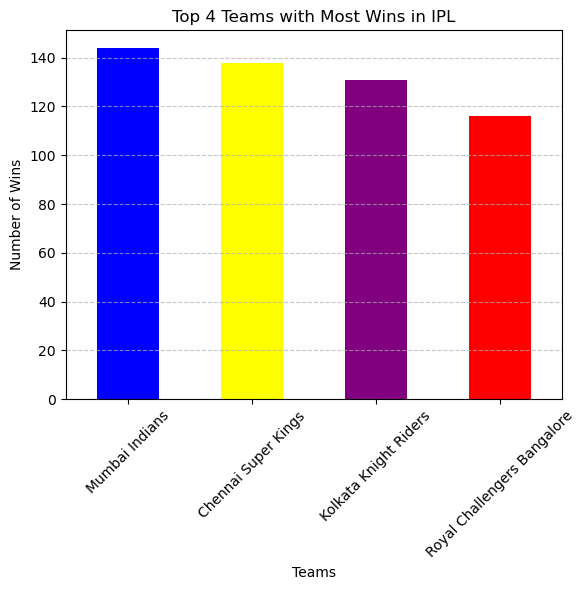

In [13]:

jersey_colors = {
    'Mumbai Indians': 'blue',
    'Chennai Super Kings': 'yellow',
    'Kolkata Knight Riders': 'purple',
    'Royal Challengers Bangalore': 'red'
}

# Create color list based on team names
colors = [jersey_colors[team] for team in top_4_teams.index]
plt.figure(figsize=(6, 6))
top_4_teams.plot(kind='bar', color=colors)
plt.title('Top 4 Teams with Most Wins in IPL')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [17]:
import pandas as pd

# Assuming you have a DataFrame named df
# with columns: team1, team2, and winner

def get_loser(row):
    if row['winner'] == row['team1']:
        return row['team2']
    elif row['winner'] == row['team2']:
        return row['team1']
    else:
        return None  # For cases like No Result or Tie
match=pd.read_csv("matches.csv")
match['loser'] = match.apply(get_loser, axis=1)

In [27]:
match.shape


(1095, 21)

In [19]:
bottom_4_teams = match['loser'].value_counts().head(4)
print("Bottom 4 teams with most loss:")
for team, loser in bottom_4_teams.items():
    print(f"{team}: {loser} loss")

Bottom 4 teams with most loss:
Royal Challengers Bangalore: 121 loss
Kolkata Knight Riders: 120 loss
Mumbai Indians: 117 loss
Rajasthan Royals: 107 loss


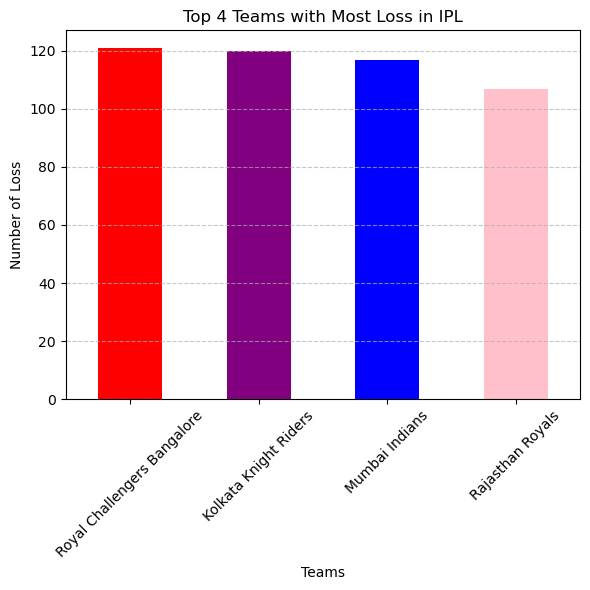

In [21]:
jersey_colors = {
    'Mumbai Indians': 'blue',
    'Rajasthan Royals': 'pink',
    'Kolkata Knight Riders': 'purple',
    'Royal Challengers Bangalore': 'red'
}

# Create color list based on team names
colors = [jersey_colors[team] for team in bottom_4_teams.index]
plt.figure(figsize=(6, 6))
bottom_4_teams.plot(kind='bar', color=colors)
plt.title('Top 4 Teams with Most Loss in IPL')
plt.xlabel('Teams')
plt.ylabel('Number of Loss')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
# player who won most of man of the match awards
Top_5_Most_POM=match["player_of_match"].value_counts().head(5)
print(Top_5_Most_POM)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
Name: count, dtype: int64


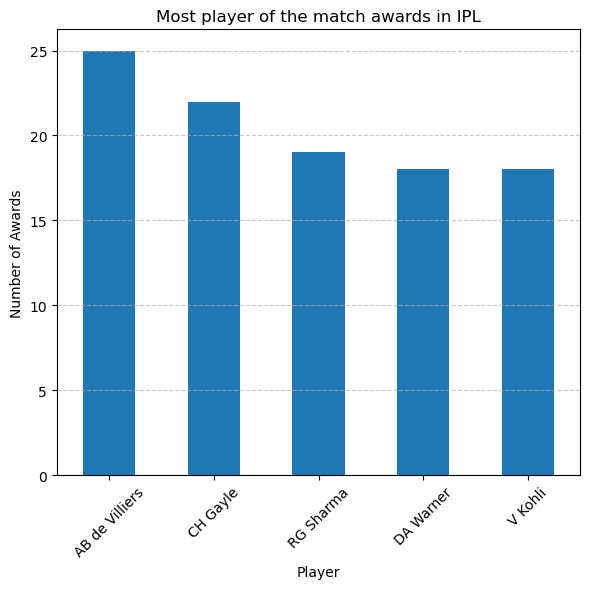

In [29]:
plt.figure(figsize=(6, 6))
Top_5_Most_POM.plot(kind='bar')
plt.title('Most player of the match awards in IPL')
plt.xlabel('Player')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:




# Step 3: Calculate wins by batting first and second
# Batting first: win_by_runs > 0
batting_first_wins =( match['win by']=='runs').sum()

# Batting second: win_by_wickets > 0
batting_second_wins = (match['win by']=='wickets').sum()

# Step 4: Print the results
print("Matches won by batting first:", batting_first_wins)
print("Matches won by batting second:", batting_second_wins)


Matches won by batting first: 498
Matches won by batting second: 578


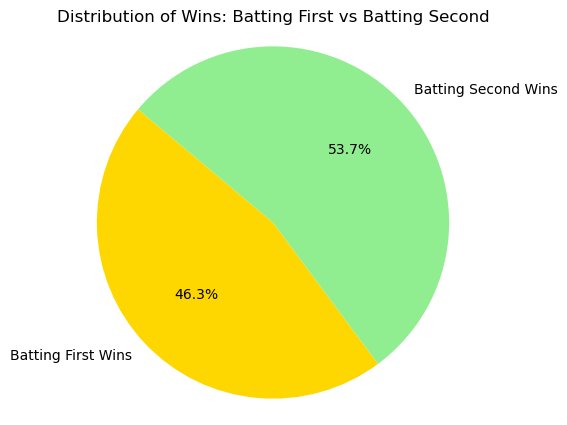

In [49]:
labels = ['Batting First Wins', 'Batting Second Wins']
sizes = [batting_first_wins, batting_second_wins]
colors = ['gold', 'lightgreen']

# Create pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Wins: Batting First vs Batting Second')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

In [71]:
print(match.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'win by', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


# **Toss Winner Vs Match Winner Percentage**

In [86]:
Percentage=(match['toss_winner']==match['winner']).mean()*100
print(f"Toss winner wins the match {Percentage:.2f,}% of the time")

Toss winner wins the match 50.59% of the time


In [15]:

# Find close matches
close_matches = match[
    ((match['win by'] == 'runs') & (match['result_margin'] <= 10)) |
    ((match['win by'] == 'wickets') & (match['result_margin'] <= 2))
]

print(close_matches[['id', 'city', 'date', 'team1', 'team2', 'winner', 'win by', 'result_margin']].head(5).to_string(index=False))




    id       city       date                       team1                       team2                      winner win by  result_margin
335989    Chennai 2008-04-23         Chennai Super Kings              Mumbai Indians         Chennai Super Kings   runs            6.0
335998      Delhi 2008-04-30            Delhi Daredevils Royal Challengers Bangalore            Delhi Daredevils   runs           10.0
336003 Chandigarh 2008-05-03             Kings XI Punjab       Kolkata Knight Riders             Kings XI Punjab   runs            9.0
336034  Bangalore 2008-05-03 Royal Challengers Bangalore             Deccan Chargers Royal Challengers Bangalore   runs            3.0
336010    Kolkata 2008-05-08       Kolkata Knight Riders Royal Challengers Bangalore       Kolkata Knight Riders   runs            5.0


In [51]:
import pandas as pd

# Load the file
deliveries = pd.read_csv('deliveries(2).csv')

# Filter where batsman hit 4 runs
fours = deliveries[deliveries['batsman_runs'] == 4]

# Count number of 4s by each batsman
fours_by_batsman = fours['batter'].value_counts()

# Display top 5 batsmen with most 4s
print(fours_by_batsman.head(5))


batter
S Dhawan     768
V Kohli      708
DA Warner    663
RG Sharma    599
SK Raina     506
Name: count, dtype: int64


In [53]:
Sixes = deliveries[deliveries['batsman_runs'] == 6]

# Count number of 4s by each batsman
Sixes_by_batsman = Sixes['batter'].value_counts()

# Display top 5 batsmen with most 4s
print(Sixes_by_batsman.head(5))

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
Name: count, dtype: int64


In [36]:
Dismissed_by_bold=deliveries[deliveries['dismissal_kind'] == "bowled"]
Batsman_bold=Dismissed_by_bold['batter'].value_counts()
print(Batsman_bold.head(5))

batter
S Dhawan     40
V Kohli      39
SR Watson    36
DA Warner    30
MK Pandey    30
Name: count, dtype: int64


In [7]:
import pandas as pd

# Load the file
deliveries = pd.read_csv('deliveries(2).csv')
Top_5_bowler=deliveries[deliveries['is_wicket'] ==1]
Top_5_bowler_wicket=Top_5_bowler['bowler'].value_counts()
print(Top_5_bowler_wicket.head(5))


bowler
YS Chahal    213
DJ Bravo     207
PP Chawla    201
SP Narine    200
R Ashwin     198
Name: count, dtype: int64


#**Top 5 Batsman with Most Dot Balls**


In [27]:
Top_5_batsman=deliveries[deliveries['batsman_runs'] ==0]
Top_5_batsman_dot_ball=Top_5_batsman['batter'].value_counts()
Top_5_batsman_dot_ball=Top_5_batsman_dot_ball.astype(str)+" "+ 'balls'
print(Top_5_batsman_dot_ball.head(5))

batter
V Kohli      2198 balls
S Dhawan     2136 balls
RG Sharma    2036 balls
DA Warner    1873 balls
CH Gayle     1636 balls
Name: count, dtype: object


In [ ]:
#**TOP 10 BATSMAN BY RUN **

C:\Users\Md Imtiaz\AppData\Local\Temp\ipykernel_5008\147719923.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='viridis')


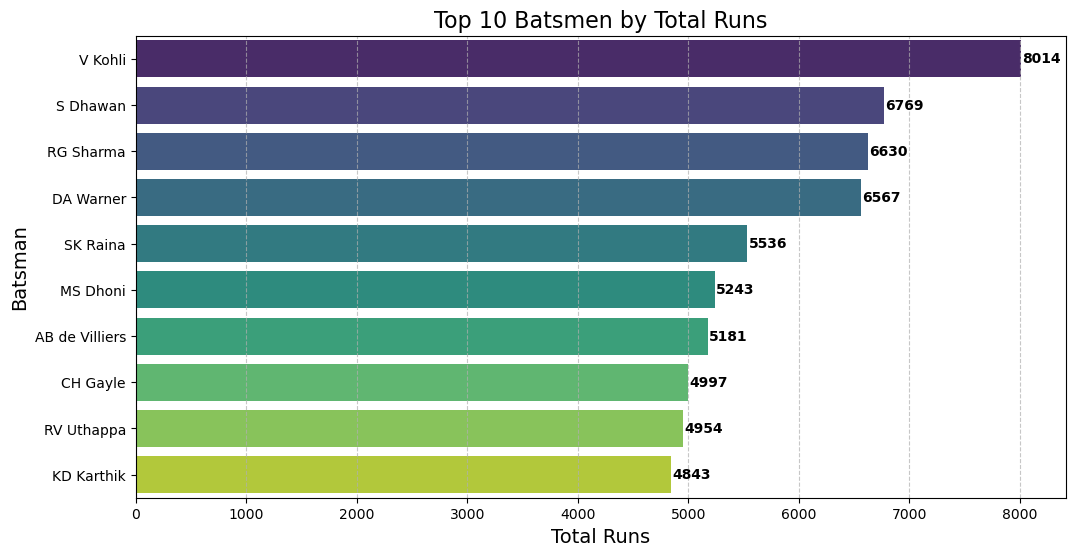

In [5]:
# Import libraries
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (already done in your case)
deliveries = pd.read_csv('deliveries(2).csv')

# Group by batter and sum the batsman runs
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

# Plotting the bar graph
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='viridis')

# Add the run values on the bars
for i, v in enumerate(top_batsmen.values):
    ax.text(v + 10, i, str(v), color='black', va='center', fontweight='bold')

# Titles and labels
plt.title('Top 10 Batsmen by Total Runs', fontsize=16)
plt.xlabel('Total Runs', fontsize=14)
plt.ylabel('Batsman', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()




In [ ]:
#**Orange Cap holder for each season**

In [81]:
deliveries = pd.read_csv('deliveries(2).csv')
match = pd.read_csv('matches (2).csv')
merged = deliveries.merge(match[['id', 'season']], left_on='match_id', right_on='id')

# Group by season and batter to calculate total runs
season_runs = merged.groupby(['season', 'batter'])['batsman_runs'].sum().reset_index()

# Sort and pick the top scorer (Orange Cap) for each season
orange_caps = season_runs.sort_values(['season', 'batsman_runs'], ascending=[True, False]) \
                         .drop_duplicates('season') \
                         .sort_values('season')

print(orange_caps)

       season         batter  batsman_runs
115   2007/08       SE Marsh           616
229      2009      ML Hayden           572
446   2009/10   SR Tendulkar           618
502      2011       CH Gayle           608
684      2012       CH Gayle           733
910      2013     MEK Hussey           733
1088     2014     RV Uthappa           660
1148     2015      DA Warner           562
1383     2016        V Kohli           973
1422     2017      DA Warner           641
1594     2018  KS Williamson           735
1694     2019      DA Warner           692
1866  2020/21       KL Rahul           676
2051     2021     RD Gaikwad           635
2144     2022     JC Buttler           863
2423     2023   Shubman Gill           890
2606     2024        V Kohli           741


#**Purple Cup Holder for each season**

In [83]:


# Merge to include season info
merged = deliveries.merge(match[['id', 'season']], left_on='match_id', right_on='id')

# Filter only valid dismissals that count as a bowler's wicket
valid_dismissals = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets = merged[merged['dismissal_kind'].isin(valid_dismissals)]

# Group by season and bowler to count wickets
season_wickets = wickets.groupby(['season', 'bowler']).size().reset_index(name='wickets')

# Get top wicket-taker per season
purple_caps = season_wickets.sort_values(['season', 'wickets'], ascending=[True, False]) \
                            .drop_duplicates('season') \
                            .sort_values('season')

print(purple_caps)


       season          bowler  wickets
75    2007/08   Sohail Tanvir       22
152      2009        RP Singh       23
241   2009/10         PP Ojha       21
367      2011      SL Malinga       28
437      2012        M Morkel       25
509      2013        DJ Bravo       32
638      2014       MM Sharma       23
694      2015        DJ Bravo       26
773      2016         B Kumar       23
860      2017         B Kumar       26
942      2018          AJ Tye       24
1048     2019     Imran Tahir       26
1141  2020/21        K Rabada       32
1211     2021        HV Patel       32
1378     2022       YS Chahal       27
1447     2023  Mohammed Shami       28
1515     2024        HV Patel       24
